# Baseline QGRU — hyperparameter tuning

Sweeps the vom-Scheidt search axes (recurrent size × dense size × learning rate) with
values adapted to this project's 456-output monotone head, selects on **validation
pinball**, and saves the single best early-stopped model as a rebuildable checkpoint.

**Runs from the same folder as `forecasting.py`** (imports the tested core from it).

Decisions baked in (from the pipeline contract):
- split: **year / half-year / year** (train 2018 · val 2019-H1 · test 2019-H2→2020-H1)
- **all-hours augmented** origins for the baseline (`gate_aligned_only=False`)
- scaler fit on the **train span only**; validation-based selection; **test never touched here**
- pinball loss = **sum over K and Q, averaged per batch** (same reduction for train, val, and the DFL warm-start)
- early stopping: **patience 10 · max 200 epochs · restore best weights**
- searched: `gru_hidden ∈ {4,8,16,32}`, `dense ∈ {8,16,32,64}`, `lr ∈ {0.001,0.005,0.01}` (36 configs)
- fixed (not searched): dropout 0.1 · weight_decay 1e-4 · 2 GRU layers · eps 1e-4 · batch 64


## 0. Setup colab environment

In [1]:
import os
import sys
from google.colab import drive
import shutil
from pathlib import Path

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted.")

# 2. Define and create base directory
BASE_DIR = Path("/content/drive/MyDrive/UCL/Dissertation/model_training")
os.makedirs(BASE_DIR, exist_ok=True)
sys.path.insert(0, str(BASE_DIR)) # make forecasting module importable
base_dir_path = str(BASE_DIR)
print(f"Base directory created at: {base_dir_path}")

# 3. Add forecasting.py as an importable python file
forecasting_file_dir = os.path.join(BASE_DIR, "forecasting.py")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted.
Base directory created at: /content/drive/MyDrive/UCL/Dissertation/model_training


## 1 · Imports & reproducibility

In [2]:
!pip install pyprojroot

In [3]:
import copy
import time
import random
import subprocess

import numpy as np
import pandas as pd
import torch
#from pyprojroot import here

# tested core — same directory
from forecasting import (
    QUANTILE_LEVELS, HIST_COLS, FEAT_COLS, EXO_COLS,
    TRAIN_START, VAL_START, TEST_START, TEST_END,
    build_features, reindex_and_impute, make_windows,
    fit_scalers, normalise_hist, normalise_exo, normalise_y,
    Baseline_Forecaster, pinball_loss,
)


In [4]:
# ---- reproducibility (record SEED in the checkpoint) ----
SEED = 20240801
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| seed:", SEED)


device: cuda | seed: 20240801


## 2 · Search grid & fixed hyperparameters

In [5]:
# ---- searched axes (vom-Scheidt structure; capacities/LR adapted to the 456-output head) ----

# First search
#GRU_HIDDEN_GRID  = [4, 8, 16, 32]
#DENSE_WIDTH_GRID = [8, 16, 32, 64]
#LR_GRID          = [0.001, 0.005, 0.01]
## search came back with {'gru_hidden_size': 8, 'dense_hidden_width': 64, 'lr': 0.001} as optimal model
# based on this, I extended the search area to include a learning rate of 0.0005 and a linear hidden density of 128.

# Second search
GRU_HIDDEN_GRID  = [4, 8, 16, 32]
DENSE_WIDTH_GRID = [8, 16, 32, 64, 128]
LR_GRID          = [0.0005, 0.001, 0.005, 0.01]

GRID = [
    {"gru_hidden_size": g, "dense_hidden_width": d, "lr": lr}
    for g in GRU_HIDDEN_GRID
    for d in DENSE_WIDTH_GRID
    for lr in LR_GRID
]
print(f"{len(GRID)} configs in the sweep")

# ---- fixed across EVERY config (no hidden degrees of freedom in the search) ----
DROPOUT      = 0.1
WEIGHT_DECAY = 1e-4
N_GRU_LAYERS = 2
EPS          = 1e-4
HORIZON      = 24
BATCH_SIZE   = 64

# ---- early stopping ----
MAX_EPOCHS = 200
PATIENCE   = 10     # epochs with no val improvement before stopping
MIN_DELTA  = 0.0    # strict improvement required
# restore-best-weights is implemented inside train_one_config().

# pinball levels on-device; same tensor used for train and val loss
LEVELS = torch.as_tensor(QUANTILE_LEVELS, dtype=torch.float32, device=DEVICE)


80 configs in the sweep


## 3 · Load data → UTC hourly grid → features

Same preprocessing path as `forecasting.py`'s `__main__` (tz-localise → reindex+impute → build features).

In [6]:
#ROOT_DIR = here()
#DATA_DIR = ROOT_DIR / "1_data" / "processed"


base_data = pd.read_csv(BASE_DIR / "df_full.csv", parse_dates=["datetime"])
base_data.set_index("datetime", inplace=True)

if base_data.index.tz is None:
    base_data = base_data.tz_localize("UTC")
else:
    base_data = base_data.tz_convert("UTC")
base_data = base_data.sort_index()

base_data  = reindex_and_impute(base_data, HIST_COLS, freq="1h", warn_gap=6)
frame_full = build_features(base_data, feature_cols=FEAT_COLS)
print("frame_full:", frame_full.shape, "|", frame_full.index.min(), "->", frame_full.index.max())


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
frame_full: (23520, 15) | 2017-11-03 00:00:00+00:00 -> 2020-07-09 23:00:00+00:00


## 4 · Windowing — train & val only

Test split is **deliberately not built here** so tuning cannot see it. History spills back before each split's start for burn-in; the target-based `y_range` keeps split targets disjoint.

In [7]:
h = pd.Timedelta(hours=1)

Xtr = make_windows(
    frame_full, y_range=(TRAIN_START, VAL_START - h),
    gate_aligned_only=False, issue_hour=9,
    exo_cols=EXO_COLS, hist_cols=HIST_COLS, target_col="prosumption",
)
Xva = make_windows(
    frame_full, y_range=(VAL_START, TEST_START - h),
    gate_aligned_only=False, issue_hour=9,
    exo_cols=EXO_COLS, hist_cols=HIST_COLS, target_col="prosumption",
)

# seam + shape invariants
assert Xtr.de == VAL_START - h, f"train delivery end {Xtr.de} != {VAL_START - h}"
assert Xtr.x_hist.shape[1:] == (168, len(HIST_COLS))
assert Xtr.x_fut.shape[1:]  == (24, len(EXO_COLS))
assert Xtr.y.shape[1:]      == (24,)

print(f"train windows: {Xtr.x_hist.shape[0]:>6}  ({Xtr.ds} -> {Xtr.de})")
print(f"val   windows: {Xva.x_hist.shape[0]:>6}  ({Xva.ds} -> {Xva.de})")


train windows:   8737  (2018-01-01 00:00:00+00:00 -> 2018-12-31 23:00:00+00:00)
val   windows:   4321  (2019-01-01 00:00:00+00:00 -> 2019-06-30 23:00:00+00:00)


## 5 · Scale (train-only stats) → tensors

In [8]:
# scaler fit on the TRAIN span ONLY, applied to val (no leakage)
sc = fit_scalers(frame_full.loc[Xtr.hs:Xtr.de], HIST_COLS, exo_cols=EXO_COLS)
print("mu_y:", round(sc["mu_y"], 3), "| sd_y:", round(sc["sd_y"], 3))

# normalise necessary data (historical and y-value)
xh_tr = normalise_hist(Xtr.x_hist, sc); y_tr = normalise_y(Xtr.y, sc)
xh_va = normalise_hist(Xva.x_hist, sc); y_va = normalise_y(Xva.y, sc)
xf_tr = normalise_exo(Xtr.x_fut, sc); xf_va = normalise_exo(Xva.x_fut, sc)

def _t(a):
    return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

data = {
    "xh_tr": _t(xh_tr), "xf_tr": _t(xf_tr), "y_tr": _t(y_tr),
    "xh_va": _t(xh_va), "xf_va": _t(xf_va), "y_va": _t(y_va),
    "num_hist": Xtr.x_hist.shape[2],
    "num_exo":  Xtr.x_fut.shape[2],
}
print("tensor shapes:", {k: tuple(v.shape) for k, v in data.items() if torch.is_tensor(v)})


mu_y: 2.294 | sd_y: 1.395
tensor shapes: {'xh_tr': (8737, 168, 4), 'xf_tr': (8737, 24, 9), 'y_tr': (8737, 24), 'xh_va': (4321, 168, 4), 'xf_va': (4321, 24, 9), 'y_va': (4321, 24)}


## 6 · Train one config, with early stopping + restore-best

In [9]:
@torch.no_grad()
def val_pinball(model):
    model.eval()
    return pinball_loss(data["y_va"], model(data["xh_va"], data["xf_va"]), LEVELS).item()


def train_one_config(cfg, seed=SEED, verbose=False):
    # fresh, identically-seeded init + optimizer per config for a fair comparison
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = Baseline_Forecaster(
        n_hist_features=data["num_hist"],
        n_exo_features=data["num_exo"],
        n_quantiles=len(QUANTILE_LEVELS),
        gru_hidden_size=cfg["gru_hidden_size"],
        dense_hidden_width=cfg["dense_hidden_width"],
        dropout=DROPOUT, horizon=HORIZON,
        n_gru_layers=N_GRU_LAYERS, eps=EPS,
    ).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=WEIGHT_DECAY)

    n = data["xh_tr"].shape[0] # number of training windows
    best_val, best_epoch, best_state = float("inf"), -1, None
    stale = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, BATCH_SIZE):
            b = perm[i:i + BATCH_SIZE]
            opt.zero_grad()
            loss = pinball_loss(
                data["y_tr"][b], model(data["xh_tr"][b], data["xf_tr"][b]), LEVELS
            )
            loss.backward()
            opt.step()

        v = val_pinball(model)
        if v < best_val - MIN_DELTA:
            best_val, best_epoch = v, epoch
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                break
        if verbose:
            print(f"  epoch {epoch:3d} | val {v:.4f} | best {best_val:.4f}@{best_epoch}")

    model.load_state_dict(best_state)   # restore best weights
    return model, best_val, best_epoch


## 7 · Run the sweep

36 configs. Selection is purely on validation pinball; the best model's weights are kept in memory for the checkpoint.

In [10]:
results = []
best_overall = {"val": float("inf")}
t0 = time.time()

for j, cfg in enumerate(GRID, 1):
    model, best_val, best_epoch = train_one_config(cfg, seed = SEED, verbose=True)
    results.append({**cfg, "val_pinball": best_val, "best_epoch": best_epoch})
    print(f"[{j:>2}/{len(GRID)}] gru={cfg['gru_hidden_size']:>2} "
          f"dense={cfg['dense_hidden_width']:>2} lr={cfg['lr']:<5} "
          f"-> val {best_val:.4f} @ epoch {best_epoch}")
    if best_val < best_overall["val"]:
        best_overall = {
            "val": best_val, "epoch": best_epoch, "cfg": cfg,
            "state": copy.deepcopy(model.state_dict()),
        }

print(f"\nsweep done in {time.time() - t0:.0f}s | "
      f"best val {best_overall['val']:.4f} with {best_overall['cfg']}")


  epoch   1 | val 774.4292 | best 774.4292@1
  epoch   2 | val 148.0028 | best 148.0028@2
  epoch   3 | val 107.4053 | best 107.4053@3
  epoch   4 | val 95.8759 | best 95.8759@4
  epoch   5 | val 89.2240 | best 89.2240@5
  epoch   6 | val 82.8810 | best 82.8810@6
  epoch   7 | val 78.3943 | best 78.3943@7
  epoch   8 | val 73.9769 | best 73.9769@8
  epoch   9 | val 72.1143 | best 72.1143@9
  epoch  10 | val 69.1772 | best 69.1772@10
  epoch  11 | val 67.8075 | best 67.8075@11
  epoch  12 | val 65.7947 | best 65.7947@12
  epoch  13 | val 64.1491 | best 64.1491@13
  epoch  14 | val 63.5029 | best 63.5029@14
  epoch  15 | val 63.3176 | best 63.3176@15
  epoch  16 | val 62.0891 | best 62.0891@16
  epoch  17 | val 61.5837 | best 61.5837@17
  epoch  18 | val 60.1833 | best 60.1833@18
  epoch  19 | val 58.8773 | best 58.8773@19
  epoch  20 | val 59.1281 | best 58.8773@19
  epoch  21 | val 60.0463 | best 58.8773@19
  epoch  22 | val 59.5665 | best 58.8773@19
  epoch  23 | val 59.3570 | best 58

## 8 · Results table

In [20]:
res_df

,gru_hidden_size,dense_hidden_width,lr,val_pinball,best_epoch
0,32,128,0.0005,41.846107,24
1,16,128,0.0005,42.054321,24
2,4,128,0.0005,42.287949,19
3,32,128,0.0100,42.386108,3
4,4,128,0.0050,42.546516,11
...,...,...,...,...,...
75,8,8,0.0005,55.944798,36
76,16,8,0.0005,56.164070,33
77,32,16,0.0005,60.002430,33
78,32,8,0.0005,60.037952,36


In [11]:
res_df = pd.DataFrame(results).sort_values("val_pinball").reset_index(drop=True)
res_df


,gru_hidden_size,dense_hidden_width,lr,val_pinball,best_epoch
0,32,128,0.0005,41.846107,24
1,16,128,0.0005,42.054321,24
2,4,128,0.0005,42.287949,19
3,32,128,0.0100,42.386108,3
4,4,128,0.0050,42.546516,11
...,...,...,...,...,...
75,8,8,0.0005,55.944798,36
76,16,8,0.0005,56.164070,33
77,32,16,0.0005,60.002430,33
78,32,8,0.0005,60.037952,36


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 9 · Save best checkpoint

Bundle stores everything the DFL warm-start needs: rebuildable `model_config`, the **train-only scaler**, quantile levels, split dates, seed, git sha, and the full grid for the write-up. Saves a `state_dict` (not a pickled module) so it survives refactors and torch upgrades.

In [ ]:
best_cfg = best_overall["cfg"]
model_config = {
    "n_hist_features":    data["num_hist"],
    "n_exo_features":     data["num_exo"],
    "n_quantiles":        len(QUANTILE_LEVELS),
    "gru_hidden_size":    best_cfg["gru_hidden_size"],
    "dense_hidden_width": best_cfg["dense_hidden_width"],
    "dropout":            DROPOUT,
    "horizon":            HORIZON,
    "n_gru_layers":       N_GRU_LAYERS,
    "eps":                EPS,
}

try:
    git_sha = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=str(here())
    ).decode().strip()
except Exception:
    git_sha = None

OUT_DIR = BASE_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = OUT_DIR / "baseline_forecaster_best.pt"

torch.save({
    "state_dict":      best_overall["state"],
    "model_config":    model_config,
    "best_lr":         best_cfg["lr"],
    "scaler_stats":    sc,
    "quantile_levels": QUANTILE_LEVELS,
    "split_dates": {
        "train": (str(TRAIN_START), str(VAL_START - h)),
        "val":   (str(VAL_START),   str(TEST_START - h)),
        "test":  (str(TEST_START),  str(TEST_END)),
    },
    "fixed_hparams": {
        "dropout": DROPOUT, "weight_decay": WEIGHT_DECAY,
        "n_gru_layers": N_GRU_LAYERS, "eps": EPS, "batch_size": BATCH_SIZE,
    },
    "early_stopping": {"max_epochs": MAX_EPOCHS, "patience": PATIENCE, "min_delta": MIN_DELTA},
    "val_pinball":  best_overall["val"],
    "best_epoch":   best_overall["epoch"],
    "seed":         SEED,
    "git_sha":      git_sha,
    "grid_results": results,
}, ckpt_path)

print("saved:", ckpt_path)
print("best config:", best_cfg, "| val pinball:", round(best_overall["val"], 4),
      "| epoch:", best_overall["epoch"])


saved: /content/drive/MyDrive/UCL/Dissertation/model_training/baseline_forecaster_best.pt
best config: {'gru_hidden_size': 32, 'dense_hidden_width': 128, 'lr': 0.0005} | val pinball: 41.8461 | epoch: 24


## 10. Break tie between best smaller models
All the best models had 128 neuron layers, but they had minimal improvement on other models, and a very small number of epochs.

Based on this, choose the next-best models that don't use 128 neurons.

These models are:

| gru_hidden_size | dense_hidden_width | lr | val_pinball | best_epoch |
| --- | --- | --- | --- | --- |
| 8 | 64 | 0.001 | 53.216732025146484 | 10 |
| 8 | 64 | 0.0005 | 53.233272552490234 | 22 |

Break tie by retraining on a set of 5 seeds, and selecting one with best characteristics (lower pinball loss mean, st.d)

In [13]:
seeds = [0, 1, 2, 3, 4]
vals = []
for s in seeds:
    _, best_val, _ = train_one_config({"gru_hidden_size":8,"dense_hidden_width":64,"lr":0.0005}, seed=s)
    vals.append(best_val)
import numpy as np
print("mean", np.mean(vals), "sd", np.std(vals, ddof=1), "range", min(vals), max(vals))

mean 42.43147354125976 sd 0.503185532799649 range 41.73322296142578 43.013465881347656


In [14]:
seeds = [0, 1, 2, 3, 4]
vals = []
for s in seeds:
    _, best_val, _ = train_one_config({"gru_hidden_size":8,"dense_hidden_width":64,"lr":0.001}, seed=s)
    vals.append(best_val)
import numpy as np
print("mean", np.mean(vals), "sd", np.std(vals, ddof=1), "range", min(vals), max(vals))

mean 42.786520385742186 sd 0.6886142882874037 range 41.98613739013672 43.60114288330078


lr of 0.0005 wins with lower mean and st.d.


## 11. Retrain, save best smallest model that wone tie-breaker.

In [15]:
final_cfg = {"gru_hidden_size":8,"dense_hidden_width":64,"lr":0.0005}

final_model, final_val, final_epoch = train_one_config(final_cfg, seed = SEED, verbose=True)

final_overall = {
            "val": final_val, "epoch": final_epoch, "cfg": final_cfg,
            "state": copy.deepcopy(final_model.state_dict()),
        }


final_model_config = {
    "n_hist_features":    data["num_hist"],
    "n_exo_features":     data["num_exo"],
    "n_quantiles":        len(QUANTILE_LEVELS),
    "gru_hidden_size":    final_cfg["gru_hidden_size"],
    "dense_hidden_width": final_cfg["dense_hidden_width"],
    "dropout":            DROPOUT,
    "horizon":            HORIZON,
    "n_gru_layers":       N_GRU_LAYERS,
    "eps":                EPS,
}

try:
    git_sha = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=str(here())
    ).decode().strip()
except Exception:
    git_sha = None

OUT_DIR = BASE_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
final_ckpt_path = OUT_DIR / "baseline_forecaster_small_not_used.pt"

torch.save({
    "state_dict":      final_overall["state"],
    "model_config":    model_config,
    "best_lr":         final_cfg["lr"],
    "scaler_stats":    sc,
    "quantile_levels": QUANTILE_LEVELS,
    "split_dates": {
        "train": (str(TRAIN_START), str(VAL_START - h)),
        "val":   (str(VAL_START),   str(TEST_START - h)),
        "test":  (str(TEST_START),  str(TEST_END)),
    },
    "fixed_hparams": {
        "dropout": DROPOUT, "weight_decay": WEIGHT_DECAY,
        "n_gru_layers": N_GRU_LAYERS, "eps": EPS, "batch_size": BATCH_SIZE,
    },
    "early_stopping": {"max_epochs": MAX_EPOCHS, "patience": PATIENCE, "min_delta": MIN_DELTA},
    "val_pinball":  final_overall["val"],
    "best_epoch":   final_overall["epoch"],
    "seed":         SEED,
    "git_sha":      git_sha,
    "grid_results": results,
}, final_ckpt_path)

print("saved:", final_ckpt_path)
print("best config:", final_cfg, "| val pinball:", round(final_overall["val"], 4),
      "| epoch:", final_overall["epoch"])


  epoch   1 | val 102.3517 | best 102.3517@1
  epoch   2 | val 66.7248 | best 66.7248@2
  epoch   3 | val 56.9161 | best 56.9161@3
  epoch   4 | val 52.2953 | best 52.2953@4
  epoch   5 | val 51.9639 | best 51.9639@5
  epoch   6 | val 49.0370 | best 49.0370@6
  epoch   7 | val 48.1384 | best 48.1384@7
  epoch   8 | val 47.0430 | best 47.0430@8
  epoch   9 | val 47.0543 | best 47.0430@8
  epoch  10 | val 46.5797 | best 46.5797@10
  epoch  11 | val 46.2209 | best 46.2209@11
  epoch  12 | val 45.2691 | best 45.2691@12
  epoch  13 | val 47.8027 | best 45.2691@12
  epoch  14 | val 46.5878 | best 45.2691@12
  epoch  15 | val 45.0440 | best 45.0440@15
  epoch  16 | val 45.4543 | best 45.0440@15
  epoch  17 | val 46.6330 | best 45.0440@15
  epoch  18 | val 45.6436 | best 45.0440@15
  epoch  19 | val 45.2299 | best 45.0440@15
  epoch  20 | val 44.9914 | best 44.9914@20
  epoch  21 | val 44.6259 | best 44.6259@21
  epoch  22 | val 45.0731 | best 44.6259@21
  epoch  23 | val 46.2484 | best 44.625

## 12. Plot best smallest model results for funsies.

In [16]:
from forecasting import denormalise_y
import matplotlib.pyplot as plt

## copied from forecasting.py as I am lazy.

# --- evaluate: monotonicity ------------------------------------- (cell 22) --
model.eval()
with torch.no_grad():
    q_va = model(data["xh_va"], data["xf_va"])  # (N, H, Q), standardised
diffs = torch.diff(q_va, dim=-1)
print("monotone (all increments > 0):", bool((diffs > 0).all()))
print("min increment:", float(diffs.min()))

q_mw = denormalise_y(torch.Tensor.cpu(q_va), sc)
assert np.all(np.diff(q_mw.numpy(), axis=-1) >= 0), (
    "physical-unit quantiles must stay ordered"
)
print("monotone after inverse-standardise: True")

# --- evaluate: coverage ----------------------------------------- (cell 23) --
with torch.no_grad():
    cover = [
        (data["y_va"].unsqueeze(-1) <= q_va[..., k : k + 1]).float().mean().item()
        for k in range(len(QUANTILE_LEVELS))
    ]
for a, c in zip(QUANTILE_LEVELS.tolist(), cover):
    print(f"level {a:.2f}:  empirical coverage {c:.3f} (abs. difference between level and empirical: {abs(a-c):.3f})")
max_dev = max(abs(a - c) for a, c in zip(QUANTILE_LEVELS.tolist(), cover))
sum_dev = sum(abs(a - c) for a, c in zip(QUANTILE_LEVELS.tolist(), cover))
print(f"\nmax |coverage - nominal| = {max_dev:.3f} \nsum |coverage - nominal| = {sum_dev:.3f} (small = well calibrated)")

monotone (all increments > 0): True
min increment: 9.989738464355469e-05
monotone after inverse-standardise: True
level 0.05:  empirical coverage 0.086 (abs. difference between level and empirical: 0.036)
level 0.10:  empirical coverage 0.099 (abs. difference between level and empirical: 0.001)
level 0.15:  empirical coverage 0.112 (abs. difference between level and empirical: 0.038)
level 0.20:  empirical coverage 0.127 (abs. difference between level and empirical: 0.073)
level 0.25:  empirical coverage 0.140 (abs. difference between level and empirical: 0.110)
level 0.30:  empirical coverage 0.221 (abs. difference between level and empirical: 0.079)
level 0.35:  empirical coverage 0.316 (abs. difference between level and empirical: 0.034)
level 0.40:  empirical coverage 0.336 (abs. difference between level and empirical: 0.064)
level 0.45:  empirical coverage 0.344 (abs. difference between level and empirical: 0.106)
level 0.50:  empirical coverage 0.486 (abs. difference between leve

In [17]:
# --- evaluate: monotonicity ------------------------------------- (cell 22) --
final_model.eval()
with torch.no_grad():
    q_va = final_model(data["xh_va"], data["xf_va"])  # (N, H, Q), standardised
diffs = torch.diff(q_va, dim=-1)
print("monotone (all increments > 0):", bool((diffs > 0).all()))
print("min increment:", float(diffs.min()))

q_mw = denormalise_y(torch.Tensor.cpu(q_va), sc)
assert np.all(np.diff(q_mw.numpy(), axis=-1) >= 0), (
    "physical-unit quantiles must stay ordered"
)
print("monotone after inverse-standardise: True")

# --- evaluate: coverage ----------------------------------------- (cell 23) --
with torch.no_grad():
    cover = [
        (data["y_va"].unsqueeze(-1) <= q_va[..., k : k + 1]).float().mean().item()
        for k in range(len(QUANTILE_LEVELS))
    ]
for a, c in zip(QUANTILE_LEVELS.tolist(), cover):
    print(f"level {a:.2f}:  empirical coverage {c:.3f} (abs. difference between level and empirical: {abs(a-c):.3f})")
max_dev = max(abs(a - c) for a, c in zip(QUANTILE_LEVELS.tolist(), cover))
sum_dev = sum(abs(a - c) for a, c in zip(QUANTILE_LEVELS.tolist(), cover))
print(f"\nmax |coverage - nominal| = {max_dev:.3f} \nsum |coverage - nominal| = {sum_dev:.3f} (small = well calibrated)")

monotone (all increments > 0): True
min increment: 0.00024008750915527344
monotone after inverse-standardise: True
level 0.05:  empirical coverage 0.132 (abs. difference between level and empirical: 0.082)
level 0.10:  empirical coverage 0.193 (abs. difference between level and empirical: 0.093)
level 0.15:  empirical coverage 0.247 (abs. difference between level and empirical: 0.097)
level 0.20:  empirical coverage 0.333 (abs. difference between level and empirical: 0.133)
level 0.25:  empirical coverage 0.359 (abs. difference between level and empirical: 0.109)
level 0.30:  empirical coverage 0.444 (abs. difference between level and empirical: 0.144)
level 0.35:  empirical coverage 0.510 (abs. difference between level and empirical: 0.160)
level 0.40:  empirical coverage 0.580 (abs. difference between level and empirical: 0.180)
level 0.45:  empirical coverage 0.601 (abs. difference between level and empirical: 0.151)
level 0.50:  empirical coverage 0.609 (abs. difference between lev

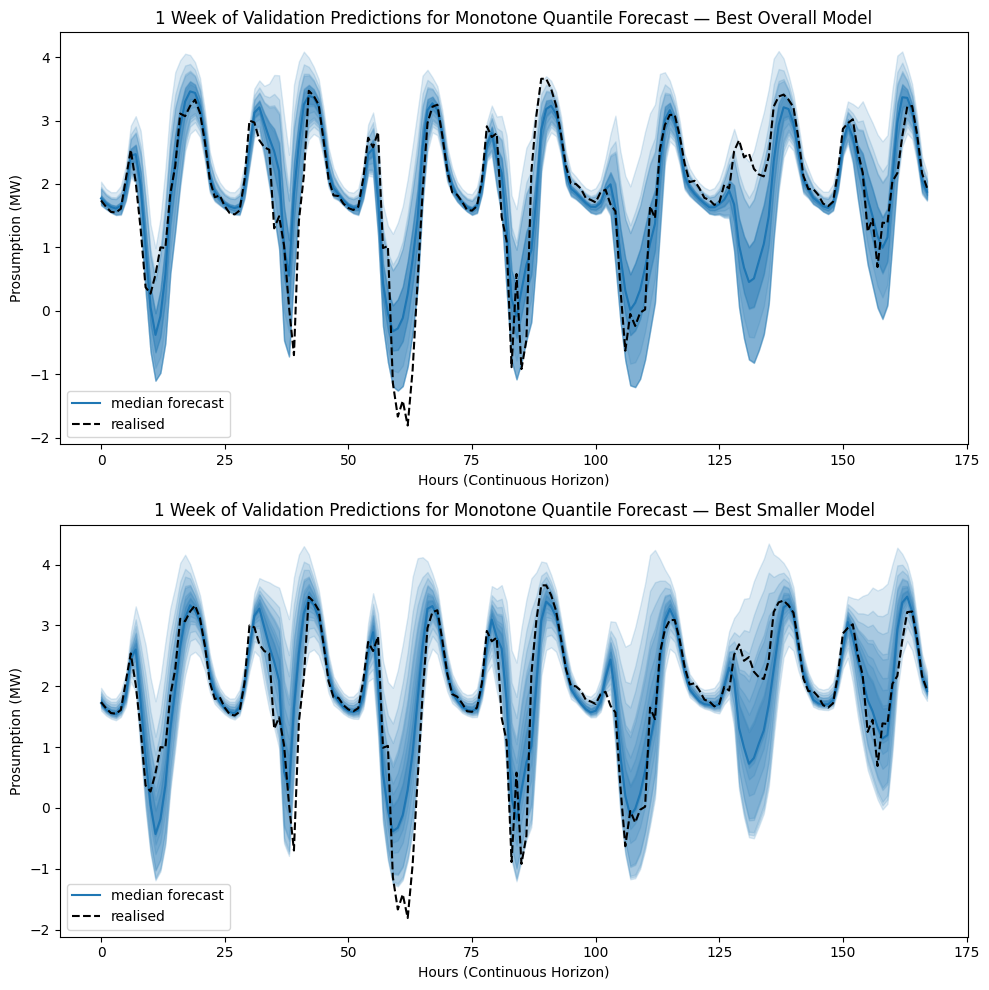

In [18]:
# Number of consecutive windows to stitch together
n_plot = 7
offset = 7 * 16

def plot_forecast(ax, model_instance, title_text):
    with torch.no_grad():
        q_va = model_instance(data["xh_va"], data["xf_va"])  # (N, HORIZON, Q), standardised

    # Move to CPU and denormalize
    q_mw = denormalise_y(q_va.cpu(), sc)

    # 1. Stitch ground truth across n_plot samples -> Shape: (n_plot * HORIZON,)
    Yva_plot = np.concatenate([np.array(Xva.y[n*24 + offset*24]).flatten() for n in range(n_plot)])

    # 2. Stitch predictions across n_plot samples -> Shape: (n_plot * HORIZON, Q)
    qp_plot = np.concatenate([q_mw.numpy()[n*24 + offset*24] for n in range(n_plot)], axis=0)

    # 3. Continuous x-axis for the stitched timeline
    hrs_plot = np.arange(HORIZON * n_plot)

    mid_plot = len(QUANTILE_LEVELS) // 2

    # Plot nested prediction bands
    for k in range(mid_plot):
        ax.fill_between(hrs_plot, qp_plot[:, k], qp_plot[:, -1 - k], alpha=0.15, color="C0")

    # Plot median forecast and realised values
    ax.plot(hrs_plot, qp_plot[:, mid_plot], color="C0", label="median forecast")
    ax.plot(hrs_plot, Yva_plot, "k--", label="realised")

    ax.set_xlabel("Hours (Continuous Horizon)")
    ax.set_ylabel("Prosumption (MW)")
    ax.set_title(title_text)
    ax.legend()

# Create a figure with two subplots arranged vertically
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for the best overall model
plot_forecast(axes[0], model, "1 Week of Validation Predictions for Monotone Quantile Forecast — Best Overall Model")

# Plot for the best smaller model (final_model)
plot_forecast(axes[1], final_model, "1 Week of Validation Predictions for Monotone Quantile Forecast — Best Smaller Model")

plt.tight_layout()
plt.show()

In [19]:
Xva.y[0:2]

array([[3.07, 2.77, 2.43, 2.18, 1.99, 1.93, 2.1 , 2.2 , 2.57, 3.03, 3.34,
        3.41, 2.15, 1.56, 2.18, 2.99, 3.93, 4.86, 4.7 , 4.23, 3.85, 3.42,
        2.96, 2.45],
       [2.77, 2.43, 2.18, 1.99, 1.93, 2.1 , 2.2 , 2.57, 3.03, 3.34, 3.41,
        2.15, 1.56, 2.18, 2.99, 3.93, 4.86, 4.7 , 4.23, 3.85, 3.42, 2.96,
        2.45, 2.55]], dtype=float32)